In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
k1 = -770690.9261910986
k2 = 7.624228003861329
k3 = 0.0020417184101237

s_1 = 35.36
s_2 = 41.6667
s_max = 74.16666667

q_list = np.linspace(0.00009, 0.00014, 1000)

pump_curve_1 = np.array(
    [k1 * q**2 + k2 * q * s_1 + 1.01930 * k3 * s_1**2 for q in q_list]
)
pump_curve_2 = np.array(
    [k1 * q**2 + k2 * q * s_2 + 0.827 * k3 * s_2**2 for q in q_list]
)

In [3]:
x1 = 0.000110859
y1 = 2.62214

x2 = 0.00010191
y2 = 2.59466

x3 = 0.00012773
y3 = 3.1192138905187794

# a = k1
# b = ((y2 - k1 * x2**2) - (y1 - k1 * x1**2)) / (x2 - x1)
# c = y1 - k1 * x1**2 - b * x1

# nk1 = a
# nk2 = b / s_1
# nk3 = c / s_1**2


# nk1, nk2, nk3 = 3.15984825, 1.0, 0.07295587
nk1, nk2, nk3 = 1.0, 57.45648878, 0.06786977  # 1.0, 57.53767864, 0.06786107

print(nk1)
print(nk2)
print(nk3)

1.0
57.45648878
0.06786977


In [4]:
new_pump_curve_1 = np.array([nk1 * q**2 + nk2 * q * s_1 + nk3 * s_1 for q in q_list])
new_pump_curve_2 = np.array([nk1 * q**2 + nk2 * q * s_2 + nk3 * s_2 for q in q_list])

(array([8.0e-05, 9.0e-05, 1.0e-04, 1.1e-04, 1.2e-04, 1.3e-04, 1.4e-04,
        1.5e-04]),
 [Text(7.999999999999999e-05, 0, '0.00008'),
  Text(8.999999999999999e-05, 0, '0.00009'),
  Text(9.999999999999999e-05, 0, '0.00010'),
  Text(0.00010999999999999999, 0, '0.00011'),
  Text(0.00011999999999999999, 0, '0.00012'),
  Text(0.00013, 0, '0.00013'),
  Text(0.00014, 0, '0.00014'),
  Text(0.00015, 0, '0.00015')])

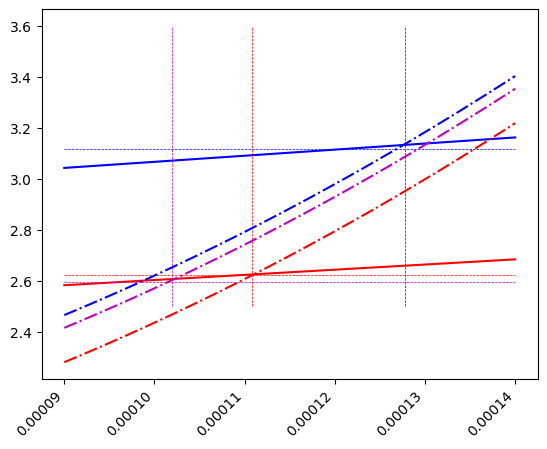

In [18]:
# plt.plot(q_list, pump_curve_1, c="r", linestyle="--", label="original pump curve 1")
# plt.plot(q_list, pump_curve_2, c="b", linestyle="--", label="original pump curve 2")

plt.plot(q_list, new_pump_curve_1, c="r", label="original pump curve 1")
plt.plot(q_list, new_pump_curve_2, c="b", label="original pump curve 2")

plt.vlines(x1, 2.5, 3.6, color="r", linestyle="--", linewidth=0.5)
plt.vlines(x2, 2.5, 3.6, color="m", linestyle="--", linewidth=0.5)
plt.vlines(x3, 2.5, 3.6, color="b", linestyle="--", linewidth=0.5)

plt.hlines(y1, q_list.min(), q_list.max(), color="r", linestyle="--", linewidth=0.5)
plt.hlines(y2, q_list.min(), q_list.max(), color="m", linestyle="--", linewidth=0.5)
plt.hlines(y3, q_list.min(), q_list.max(), color="b", linestyle="--", linewidth=0.5)

plt.plot(
    q_list,
    [
        (8 * 7.25 * 0.1035) / (np.pi**2 * 9.81 * 0.015**5) * q**2 + 1.61908
        # 1.619080192380957
        for q in q_list
    ],  # 1.1767
    c="r",
    linestyle="-.",
    label="ours: 3536/75",
)

plt.plot(
    q_list,
    [
        (8 * 7.25 * 0.1035) / (np.pi**2 * 9.81 * 0.015**5) * q**2 + 1.61908 + 0.135
        # 1.619080192380957
        for q in q_list
    ],  # 1.1767
    c="m",
    linestyle="-.",
    label="ours: 3536/50",
)

plt.plot(
    q_list,
    [
        (8 * 7.25 * 0.1035) / (np.pi**2 * 9.81 * 0.015**5) * q**2 + 1.61908 + 0.185
        # 1.619080192380957
        for q in q_list
    ],  # 1.1767
    c="b",
    linestyle="-.",
    label="ours: 4167/75",
)

plt.xticks(rotation=45, ha="right")

In [6]:
import sympy as sp

In [7]:
# Define symbols
a, b, c = sp.symbols("x y z")

# Define equations
eq1 = a * x1**2 + b * s_1 * x1 + c * s_1 - y1
eq2 = a * x2**2 + b * s_1 * x2 + c * s_1 - y2
eq3 = a * x3**2 + b * s_2 * x3 + c * s_2 - y3

solution = sp.solve([eq1, eq2, eq3], (a, b, c))

print(solution)

{x: 13205998.7008792, y: 7.37859226962694, z: 0.0687476841064746}


In [8]:
import numpy as np
from scipy.optimize import least_squares

c = k3  # fixed known value


def residuals(vars):
    a, b, c = vars
    a = k1  # fixed known value

    f1 = a * x1**2 + b * s_1 * x1 + c * s_1 - y1
    f2 = a * x2**2 + b * s_1 * x2 + c * s_1 - y2
    f3 = a * x3**2 + b * s_2 * x3 + c * s_2 - y3

    return [f1, f2, f3]


initial_guess = [1.0, 1.0, 1.0]

result = least_squares(residuals, initial_guess)

print("Solution:", result.x)
print("Residual norm:", np.linalg.norm(result.fun))

Solution: [ 1.         57.45648878  0.06786977]
Residual norm: 0.008008537243282803
